## Project Overview

> **Chips Sales Performance Analysis.**

> A fast food outlet want to understand customer purchasing behavior and product performance across its chips market. The business has transcation-level sales data that can be used to identify the most valuable customer segment, understand product performance, and track changes in consumer spending over time.

> This project aims to answer the following **business questions**:

1.   Which customer segment generates the most revenue?
2.   Which pack sizes are most popular among consumers?
3.   Which chips brand brings in the highest sales revenue?
4.   Are customers spending more per packet over time?


> **Project Objective**:

> This project aims to identify the key drivers of chips sales & customer spending, so as to enable the business to make data-driven decisions regarding its customers, chips products, and pricing.

## Setup, Import Libraries, & Load Data

In [ ]:
# Connect to drive
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
# Import relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import re

In [ ]:
# Load and preview datasets
trans_data = pd.read_excel('/content/drive/MyDrive/QVI_transaction_data.xlsx')
cust_data = pd.read_csv('/content/drive/MyDrive/QVI_purchase_behaviour.csv')
trans_data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [ ]:
cust_data.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


## Data Cleaning and Preprocessing

In [ ]:
# Change DATE col from Excel-style format to datetime format
trans_data['DATE'] = pd.to_datetime(trans_data['DATE'], unit='D', origin='1899-12-30')

# Checking for missing
print('Missing values in transcation data')
print(trans_data.isnull().sum(),'\n')
print('Missing values in customer data')
print(cust_data.isnull().sum())

# Check date range of transcations
print(
    "\nTranscations Date Range:",
    trans_data['DATE'].min(),
    "to",
    trans_data['DATE'].max()
)

# Check for duplicates
print('\nDuplicates in transcation data:', trans_data.duplicated().sum())

print('\nDuplicates in customer data:', cust_data.duplicated().sum())



Missing values in transcation data
DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64 

Missing values in customer data
LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

Transcations Date Range: 2018-07-01 00:00:00 to 2019-06-30 00:00:00

Duplicates in transcation data: 1

Duplicates in customer data: 0


In [ ]:
# Investigate the duplicates further
trans_data[trans_data.duplicated(keep=False)]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
124843,2018-10-01,107,107024,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.0
124845,2018-10-01,107,107024,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.0


In [ ]:
# The unique identifier of the transcations(TXN_ID) is similar for both records
# This seems to be a data entry error; drop the duplicates
trans_data = trans_data.drop_duplicates()
# Validate
if trans_data.duplicated().sum() == 0:
  print("Duplicates removed successfully.")

Duplicates removed successfully.


Checking for Outliers

> Boxplots are used to visualize outliers in total sales & product quantity.



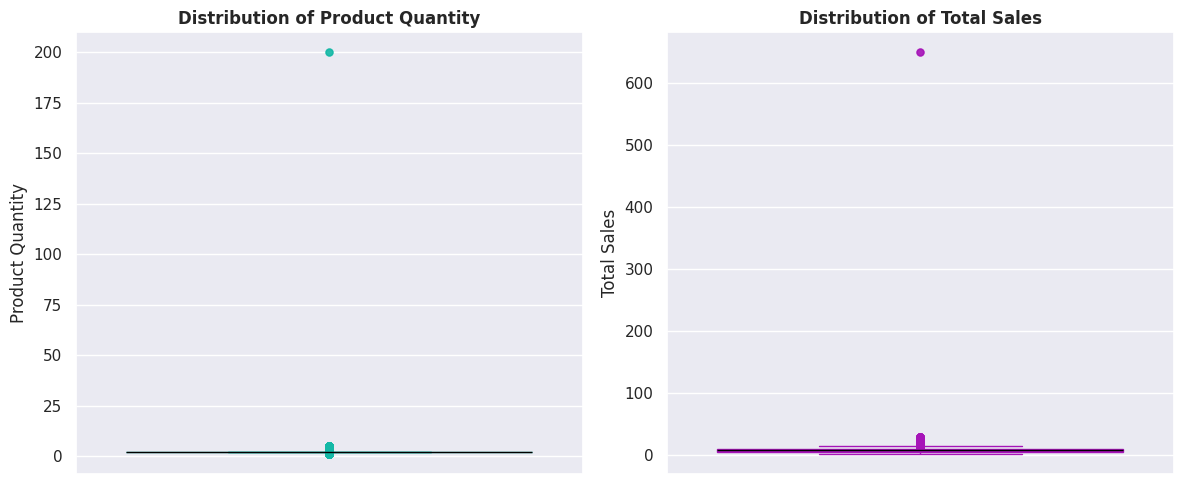

In [ ]:
# Custom color palette
custom_palette = ["#A614B8", "#14B8A6"]

# Checking outliers in Total Sales and Product Quantity
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Product Quantity
sns.boxplot(
    y=trans_data['PROD_QTY'],
    ax=axes[0],
    color=custom_palette[1],
    boxprops=dict(facecolor=custom_palette[1], edgecolor=custom_palette[1]),
    whiskerprops=dict(color=custom_palette[1]),
    capprops=dict(color=custom_palette[1]),
    medianprops=dict(color='black'),
    flierprops=dict(
        marker='o',
        markerfacecolor=custom_palette[1],
        markeredgecolor=custom_palette[1],
        markersize=5,
        alpha=0.7
    )
)

axes[0].set_title('Distribution of Product Quantity', fontweight='bold')
axes[0].set_ylabel('Product Quantity')

# Total Sales
sns.boxplot(
    y=trans_data['TOT_SALES'],
    ax=axes[1],
    color=custom_palette[0],
    boxprops=dict(facecolor=custom_palette[0], edgecolor=custom_palette[0]),
    whiskerprops=dict(color=custom_palette[0]),
    capprops=dict(color=custom_palette[0]),
    medianprops=dict(color='black'),
    flierprops=dict(
        marker='o',
        markerfacecolor=custom_palette[0],
        markeredgecolor=custom_palette[0],
        markersize=5,
        alpha=0.7
    )
)

axes[1].set_title('Distribution of Total Sales', fontweight='bold')
axes[1].set_ylabel('Total Sales')

plt.tight_layout()
plt.show()

~99% of the transcations are capped at 5 units; a quantity value of 200 seems conspicously odd and should be investigated further to determine whether it is an anomaly or a valid transcation.

In [ ]:
# Investigate the outliers further
mask = trans_data['PROD_QTY'] > 5
trans_data[mask]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [ ]:
# Customer details of the outlier transcation
mask = cust_data['LYLTY_CARD_NBR'] == 226000
cust_data[mask]

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
59694,226000,OLDER FAMILIES,Premium


The outlier transcations of 200 units was made by an elderly customer who is in the premium category; the two transcations were of the same product and quantity but were made on different dates (~9 months apart). Although the transcations are extreme compared to the overall distribution of the data, the nature of the purchases suggest valid high volume transcations rather than data entry errors. The two records will thus be retained for analysis.

In [ ]:
# Merge the datasets
df = trans_data.merge(cust_data, on='LYLTY_CARD_NBR', how='left')
print(f"df shape: {df.shape}\n")
df.head(2)

df shape: (264835, 10)



,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget


In [ ]:
# Feature Extraction

# Extract Pack size and unit
pattern = r'(\d+(?:\.\d+)?\s?)(kg|g|mg)'
df[['PCK_SIZE', 'UNIT']] = df['PROD_NAME'].str.extract(pattern, flags=re.IGNORECASE)
df['PCK_SIZE'] = df['PCK_SIZE'].astype(float)

# Extract brand name
df['BRAND'] = df['PROD_NAME'].str.extract(r'^(\S+)')
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,PCK_SIZE,UNIT,BRAND
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium,175.0,g,Natural
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget,175.0,g,CCs
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget,170.0,g,Smiths
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget,175.0,g,Smiths
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget,150.0,g,Kettle


## Data Analysis

### Revenue Contribution of Customer Segments

In [ ]:
# % of customers in each segment
seg_count = (
    df['PREMIUM_CUSTOMER']
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

seg_count.columns = ['PREMIUM_CUSTOMER', 'PERCENT_CUSTOMERS']

# % contribution of sales by segment
seg_sales = (
    df.groupby('PREMIUM_CUSTOMER')['TOT_SALES']
    .sum()
    .div(df['TOT_SALES'].sum())
    .mul(100)
    .reset_index(name='PERCENT_SALES')
)

# Combine customer share and revenue contribution
seg_analysis = seg_count.merge(
    seg_sales,
    on='PREMIUM_CUSTOMER'
)

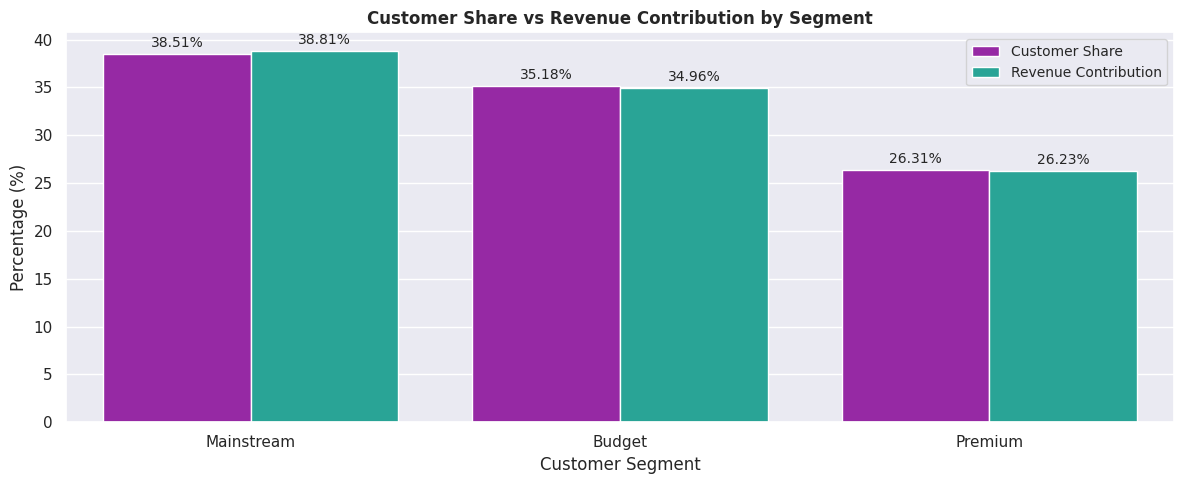

In [ ]:
# Reshape for visualization
seg_plot = seg_analysis.melt(
    id_vars='PREMIUM_CUSTOMER',
    value_vars=['PERCENT_CUSTOMERS', 'PERCENT_SALES'],
    var_name='METRIC',
    value_name='PERCENT'
)

# Rename metrics
seg_plot['METRIC'] = seg_plot['METRIC'].replace({
    'PERCENT_CUSTOMERS': 'Customer Share',
    'PERCENT_SALES': 'Revenue Contribution'
})

# Plot
plt.figure(figsize=(12, 5))

ax = sns.barplot(
    data=seg_plot,
    x='PREMIUM_CUSTOMER',
    y='PERCENT',
    hue='METRIC',
    palette=custom_palette[:2]
)

# Add bar labels
for container in ax.containers:
  ax.bar_label(
      container,
      fmt='%.2f%%',
      padding=3,
      fontsize=10
  )

plt.title('Customer Share vs Revenue Contribution by Segment', fontweight='bold')
plt.xlabel('Customer Segment')
plt.ylabel('Percentage (%)')
plt.legend(title='', fontsize=10)
plt.tight_layout()
plt.show()

Revenue contribution is relatively proportional to customer share across all segments with the Mainstream segment having the largest impact on total sales. No single segment is significantly more valuable than the other on a per-customer basis based on revenue alone.

### Sales per Pack Size

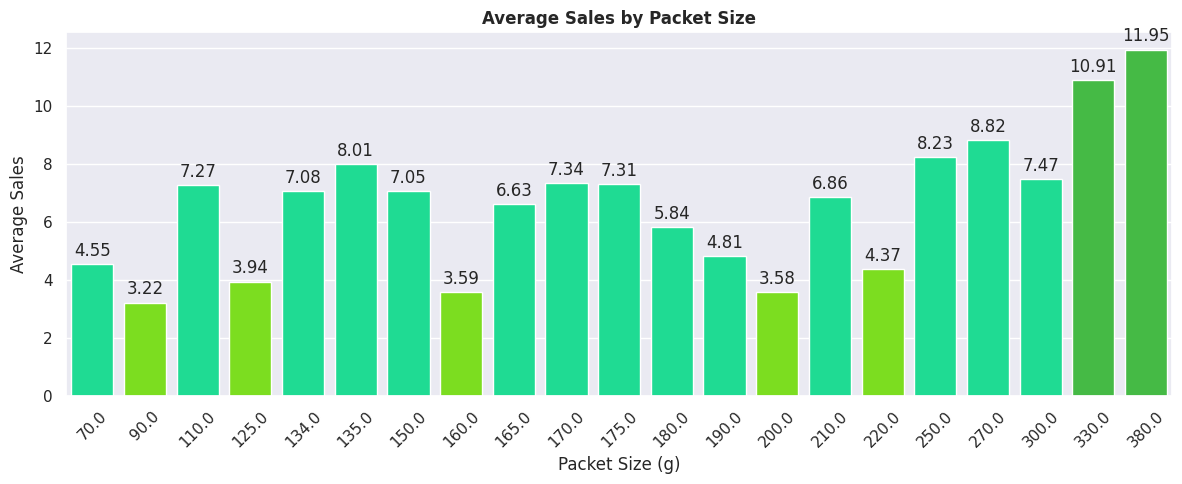

In [ ]:
# Aggregate data: average sales by pack sizes
pck_sales_data = (
    df[['PCK_SIZE', 'TOT_SALES']]
    .groupby('PCK_SIZE', as_index=False)
    .mean()
    .rename(columns={'TOT_SALES': 'AVG_SALES'})
)

# Identify highest, medium, and lowest average sales
max_idx = 10
mid_idx = 9
min_idx = 4.5

# Assign colors
custom_colors = ['#32CD32', '#00FA9A', '#7CFC00']

bar_colors = [
    custom_colors[0] if i >= max_idx else
    custom_colors[2] if i <= min_idx else
    custom_colors[1]
    for i in pck_sales_data.AVG_SALES
]

# Visualize
plt.figure(figsize=(12,5))

ax = sns.barplot(
    data=pck_sales_data,
    x='PCK_SIZE',
    y='AVG_SALES',
    palette=bar_colors,
    hue='PCK_SIZE',
    legend=False
)

# Add bar labels
for container in ax.containers:
  ax.bar_label(
    container,
    fmt='%.2f',
    padding=3
  )

plt.title('Average Sales by Packet Size', fontweight='bold')
plt.xlabel('Packet Size (g)')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Overall, larger pack sizes (300g, 330g, & 380g) tend to generate higher average sales, although the relationship is not perfectly consistent.
This suggests that larger packs may be associated with higher transaction value as compared to lower pack sizes such as 90g which generates lowest average sales.

### Brand Sales Performance

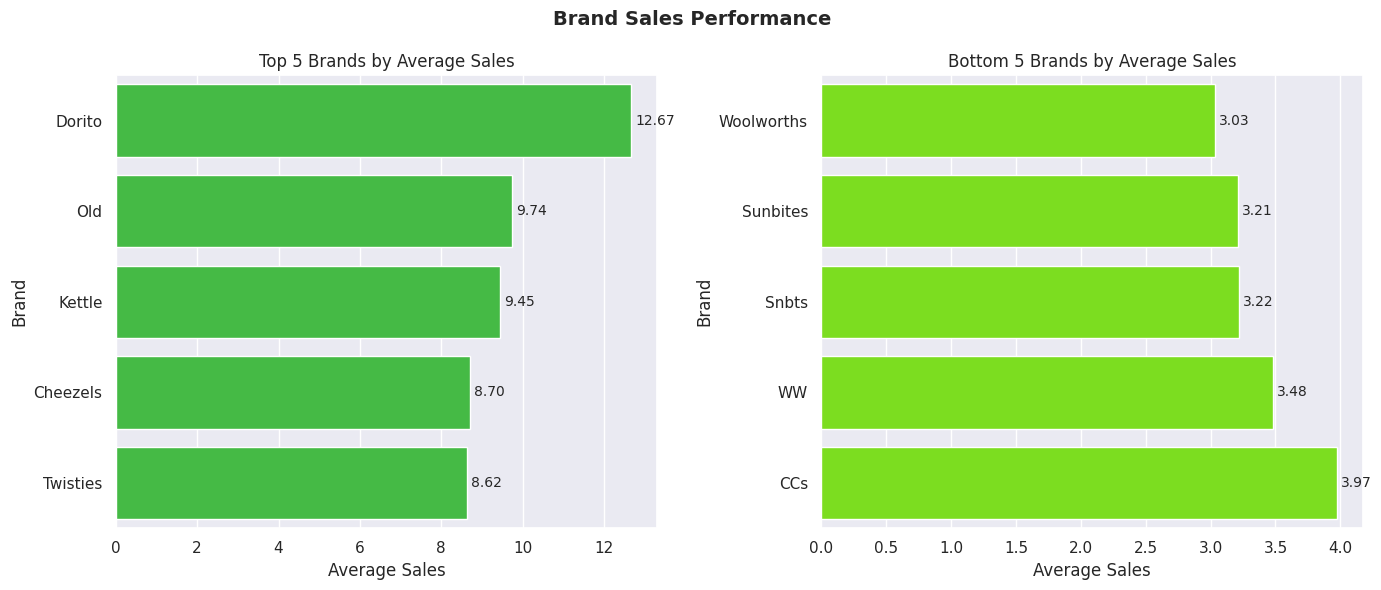

In [ ]:
# Top 5 brands
top_brands = (
    df[['BRAND', 'TOT_SALES']]
    .groupby('BRAND')
    .mean()
    .sort_values(by='TOT_SALES', ascending=False)
    .head(5)
)

# Bottom 5 brands
least_brands = (
    df[['BRAND', 'TOT_SALES']]
    .groupby('BRAND')
    .mean()
    .sort_values(by='TOT_SALES', ascending=True)
    .head(5)
)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot top 5 brands
sns.barplot(
    data=top_brands.reset_index(),
    x='TOT_SALES',
    y='BRAND',
    ax=axes[0],
    color=custom_colors[0]
)

axes[0].set_title('Top 5 Brands by Average Sales')
axes[0].set_xlabel('Average Sales')
axes[0].set_ylabel('Brand')

axes[0].bar_label(
    axes[0].containers[0],
    fmt='%.2f',
    padding=3,
    fontsize=10
)


# Plot bottom 5 brands
sns.barplot(
    data=least_brands.reset_index(),
    x='TOT_SALES',
    y='BRAND',
    ax=axes[1],
    color=custom_colors[2]
)

axes[1].set_title('Bottom 5 Brands by Average Sales')
axes[1].set_xlabel('Average Sales')
axes[1].set_ylabel('Brand')

axes[1].bar_label(
    axes[1].containers[0],
    fmt='%.2f',
    padding=3,
    fontsize=10
)

plt.suptitle('Brand Sales Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

*   **Dorito** leads by a clear margin, with the highest average sales per transaction at 12.67, followed by **Old El Passo**(9.74) and **Kettle** (9.45).

*   Twisties and Cheezels also perform strongly, averaging 8.62–8.70 per transaction.

*   Woolworths has the lowest average sales at 3.03, followed by Sunbites (3.21).
*   The gap between the highest and lowest-performing brands is substantial: Dorito averages over 4× Woolworths' sales per transaction.

### Expenditure per Chip Pack over Time

> **Business Question:** Are customers spending more per chip pack over time?



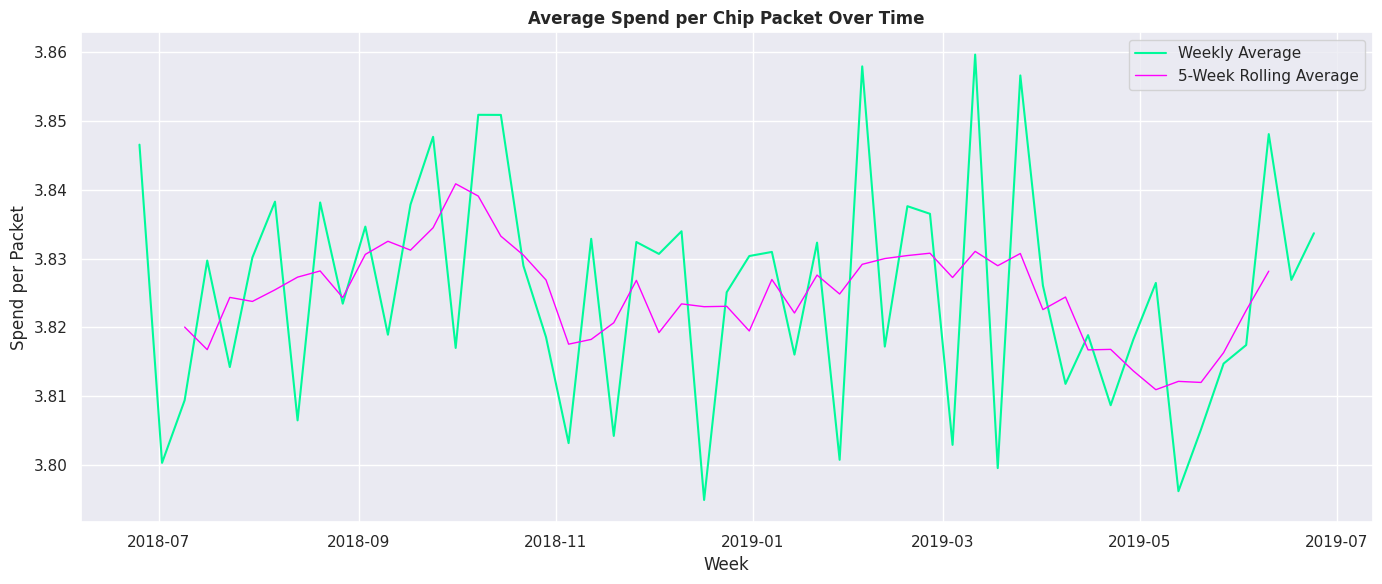

In [ ]:
# Are customers spending more per chip packet over time?
df['Spend_per_Pck'] = df['TOT_SALES'] / df['PROD_QTY']

# Aggregate by week
df['Week'] = df['DATE'].dt.to_period('W').dt.to_timestamp()

trend = df.groupby('Week')['Spend_per_Pck'].mean().reset_index()
trend = trend.sort_values("Week")

trend["rolling"] = trend["Spend_per_Pck"].rolling(window=5, center=True).mean()
trend['Spend_per_Pck'] = pd.to_numeric(trend['Spend_per_Pck'], errors='coerce')

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=trend,
    x='Week',
    y='Spend_per_Pck',
    label='Weekly Average',
    linewidth=1.5,
    #alpha=0.6,
    color=custom_colors[1]
)

sns.lineplot(
    data=trend,
    x='Week',
    y='rolling',
    label='5-Week Rolling Average',
    linewidth=1,
    color='magenta'
)

plt.title('Average Spend per Chip Packet Over Time', fontweight='bold')
plt.xlabel('Week')
plt.ylabel('Spend per Packet')
plt.legend(title='')
plt.tight_layout()
plt.show()

*   Spending per packet remained remarkably stable throughout the period, staying around 3.80–3.86.
*   The 5-week rolling average shows no sustained upward trend, suggesting customers were not paying progressively more per packet over time.
*   The highest weekly average was approximately 3.86, while the lowest was about 3.79 — a relatively narrow range.
*   There are small short-term fluctuations, but they do not indicate a meaningful long-term change in price per packet.
*   **Business implication**: The franchise appears to have maintained relatively stable pricing over the period; changes in total sales are therefore more likely to be driven by sales volume, product mix, or customer behaviour rather than increasing spend per packet.






